In [1]:
#Ejercicio 5.1 - Falta el archivo chr22_GRCh28.fasta en el repo, asi que no lo pude hacer. 
#Ejercicio 5.2 
#Leer FASTA
#Cargamos positivos
from Bio import SeqIO

def load_fasta(path):
    return [str(record.seq) for record in SeqIO.parse(path, "fasta")]

positives = load_fasta("../sequences_upper.fasta")

print(len(positives), len(positives[0])) #El conjunto de secuencias positivas tiene 561 ejemplos de 100nt de largo cada uno
#Generamos negatinos
#N1 - Random 
import random

def random_dna(length):
    return ''.join(random.choices(['A','C','G','T'], k=length))

neg_N1 = [random_dna(len(seq)) for seq in positives]
#N2 - shuffle
def shuffle_seq(seq):
    seq_list = list(seq)
    random.shuffle(seq_list)
    return ''.join(seq_list)

neg_N2 = [shuffle_seq(seq) for seq in positives]
#N3 - Negativos más realistas
neg_N3 = []

for seq in positives:
    mutated = list(seq)
    for i in range(len(mutated)):
        if random.random() < 0.1:  # 10% mutación
            mutated[i] = random.choice(['A','C','G','T'])
    neg_N3.append(''.join(mutated))

561 100


In [2]:
#One hot encoding
import numpy as np

def one_hot_encode(seq):
    mapping = {'A':0, 'C':1, 'G':2, 'T':3}
    ohe = np.zeros((4, len(seq)))

    for i, base in enumerate(seq):
        if base in mapping:
            ohe[mapping[base], i] = 1

    return ohe
#padding - largo fijo
SEQ_LEN = 100
def pad_or_trim(seq, max_len=100):
    if len(seq) > max_len:
        return seq[:max_len]
    else:
        return seq + 'N'*(max_len - len(seq))
positives = [pad_or_trim(s, SEQ_LEN) for s in positives]
neg_N1   = [pad_or_trim(s, SEQ_LEN) for s in neg_N1]
neg_N2   = [pad_or_trim(s, SEQ_LEN) for s in neg_N2]
neg_N3   = [pad_or_trim(s, SEQ_LEN) for s in neg_N3]

In [3]:
#Datasets + labels. Datasets balanceados y combinando negativos
import pandas as pd
import random

negatives = neg_N1 + neg_N2 + neg_N3

# Balanceo
negatives_sample = random.sample(negatives, len(positives))

df = pd.DataFrame({
    "sequence": positives + negatives_sample,
    "label": [1]*len(positives) + [0]*len(negatives_sample)
})

df = df.sample(frac=1).reset_index(drop=True)
#control
print(df["label"].value_counts())
#Convertir en tensores
import torch

X = np.array([one_hot_encode(seq) for seq in df["sequence"]])
y = np.array(df["label"])

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

print(X.shape)  # (N, 4, 100)
#train/ test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Guardar outputs
np.save("../results/X_train.npy", X_train.numpy())
np.save("../results/X_test.npy", X_test.numpy())
np.save("../results/y_train.npy", y_train.numpy())
np.save("../results/y_test.npy", y_test.numpy())

label
1    561
0    561
Name: count, dtype: int64
torch.Size([1122, 4, 100])


In [4]:
#control
print(X.shape)
print(y.shape)

torch.Size([1122, 4, 100])
torch.Size([1122])


El dataset final contiene 1122 secuencias balanceadas: 561 positivas y 561 negativas. Las secuencias fueron codificadas mediante one-hot encoding, obteniendo un tensor de dimensión (1122, 4, 100), mientras que las etiquetas corresponden a un vector de dimensión (1122,).

In [5]:
#Ejercicio 5.3. Objetivos: Verificar que: la red funciona, el input está bien, las dimensiones cierran, entender qué hace un modelo ANTES de entrenar
#Definir la CNN
import torch
import torch.nn as nn
import torch.nn.functional as F

class DNA_CNN(nn.Module):
    def __init__(self, seq_len=100):
        super(DNA_CNN, self).__init__()

        c = 8   # número de filtros
        k = 5   # tamaño del filtro

        self.conv1 = nn.Conv1d(in_channels=4, out_channels=c, kernel_size=k)

        # tamaño de salida después de convolución
        conv_output_len = seq_len - k + 1
        conv_output_size = c * conv_output_len

        self.fc1 = nn.Linear(conv_output_size, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # convolución + activación
        x = x.view(x.size(0), -1)   # flatten
        x = torch.sigmoid(self.fc1(x))  # salida binaria
        return x
#Testear con un batch
model = DNA_CNN(seq_len=100)

test_batch = X_train[:10]

output = model(test_batch)

print("Shape:", output.shape)
print("Valores:", output[:5])

Shape: torch.Size([10, 1])
Valores: tensor([[0.5268],
        [0.5148],
        [0.5532],
        [0.5201],
        [0.5452]], grad_fn=<SliceBackward0>)


El modelo fue evaluado antes del entrenamiento, observándose que las predicciones se encuentran cercanas a 0.5 para todas las secuencias. Esto es esperable ya que los pesos de la red se inicializan aleatoriamente y el modelo no ha aprendido aún ningún patrón discriminativo.

In [6]:
#Analizar dimensiones internas
x = test_batch

x = model.conv1(x)
print("Después de conv:", x.shape)

x = F.relu(x)
x = x.view(x.size(0), -1)
print("Después de flatten:", x.shape)

Después de conv: torch.Size([10, 8, 96])
Después de flatten: torch.Size([10, 768])


Entrada: (4, 100)
Kernel: 5
Salida conv: 100 - 5 + 1 = 96
Cada filtro detecta “motifs” de ADN

In [7]:
#Métricas sin entrenar
from sklearn.metrics import accuracy_score

preds = (output.detach().numpy() > 0.5).astype(int)
true = y_train[:10].numpy()

print("Accuracy:", accuracy_score(true, preds))

Accuracy: 0.3


El modelo sin entrenamiento presenta una performance cercana al azar, lo cual confirma que el aprendizaje de patrones es necesario para obtener predicciones significativas.
Una CNN: NO sabe nada al inicio.Aaprende filtros (motifs) durante entrenamiento. Empieza prediciendo ~0.5.

Epoch 1: Train Loss=0.6963, Test Loss=0.7017
Epoch 10: Train Loss=0.6484, Test Loss=0.7099
Epoch 20: Train Loss=0.5752, Test Loss=0.7274
Epoch 30: Train Loss=0.5114, Test Loss=0.7178
Epoch 40: Train Loss=0.4512, Test Loss=0.7136
Epoch 50: Train Loss=0.4021, Test Loss=0.7225
Epoch 60: Train Loss=0.3700, Test Loss=0.7453
Epoch 70: Train Loss=0.3559, Test Loss=0.7518
Epoch 80: Train Loss=0.3280, Test Loss=0.7683
Epoch 90: Train Loss=0.3077, Test Loss=0.7887
Epoch 100: Train Loss=0.2840, Test Loss=0.8249


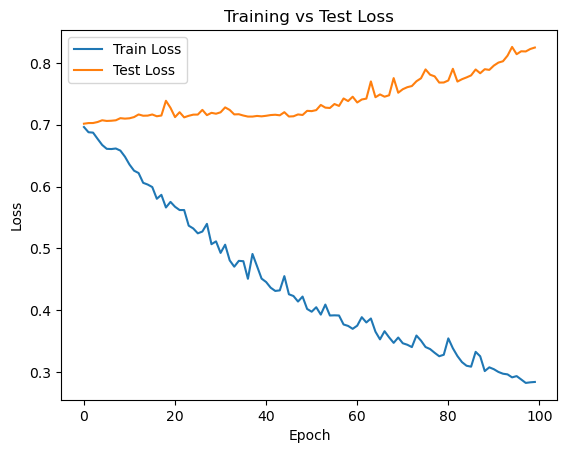


Epoch 0
Accuracy: 0.5288888888888889
F1: 0.6728395061728395
AUC: 0.5144732679531794
Confusion Matrix:
 [[ 10  99]
 [  7 109]]

Epoch 10
Accuracy: 0.48
F1: 0.44549763033175355
AUC: 0.4786459981018664
Confusion Matrix:
 [[61 48]
 [69 47]]

Epoch 50
Accuracy: 0.6044444444444445
F1: 0.6482213438735178
AUC: 0.6145998101866498
Confusion Matrix:
 [[54 55]
 [34 82]]

Epoch 100
Accuracy: 0.5822222222222222
F1: 0.5982905982905983
AUC: 0.6421227459664662
Confusion Matrix:
 [[61 48]
 [46 70]]


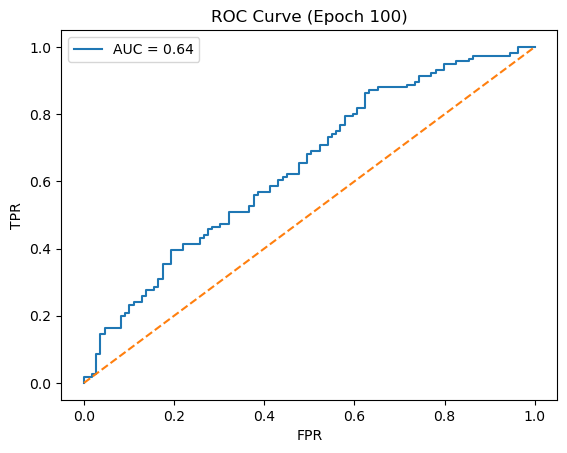

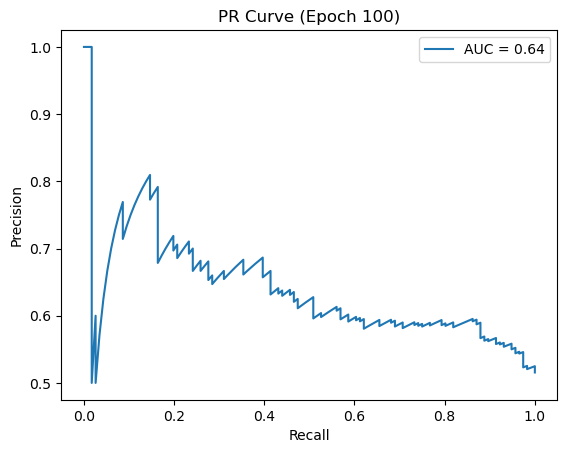

,accuracy,f1,auc
0,0.528889,0.672840,0.514473
10,0.480000,0.445498,0.478646
50,0.604444,0.648221,0.614600
100,0.582222,0.598291,0.642123


In [8]:
#Ejercicio 5.4. Objetivo: entrenar la CNN y Entrenar la CNN y comparar: modelo sin entrenar, modelo con 10, 50 y 100 épocas. Usando: Loss, Accuracy, F1-score, Matriz de confusión, ROC + AUC, PR + AUC
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score
#Definir modelo
class DNA_CNN(nn.Module):
    def __init__(self, seq_len=100):
        super(DNA_CNN, self).__init__()

        c = 8
        k = 5

        self.conv1 = nn.Conv1d(4, c, k)

        conv_output_len = seq_len - k + 1
        conv_output_size = c * conv_output_len

        self.fc1 = nn.Linear(conv_output_size, 1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        return x
#Preparar datos
model = DNA_CNN(seq_len=100)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
#Guardar modelo sin entrenar
model_0 = DNA_CNN(seq_len=100)
torch.save(model_0.state_dict(), "../results/model_epoch_0.pt")
#Entrenamiento + guardado de modelos
epochs = 100

train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in dataloader:
        output = model(batch_X).squeeze(1)
        loss = criterion(output, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(dataloader)
    train_losses.append(avg_train_loss)

    # evaluación en test
    model.eval()
    with torch.no_grad():
        test_out = model(X_test).squeeze(1)
        test_loss = criterion(test_out, y_test)

    test_losses.append(test_loss.item())

    if epoch == 0 or (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Test Loss={test_loss:.4f}")

    # guardar checkpoints
    if epoch+1 in [10, 50, 100]:
        torch.save(model.state_dict(), f"../results/model_epoch_{epoch+1}.pt")
#Curvas de loss
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.savefig("../results/loss_curve.png")
plt.show()
#Funcion de evaluacion
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_prob = model(X_test).squeeze().numpy()

    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test.numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)

    return acc, f1, cm, auc_score, y_prob
#Evaluar modelos en 0,10,50,100
results = {}

for ep in [0, 10, 50, 100]:
    model_tmp = DNA_CNN(seq_len=100)
    model_tmp.load_state_dict(torch.load(f"../results/model_epoch_{ep}.pt"))

    acc, f1, cm, auc_score, y_prob = evaluate_model(model_tmp, X_test, y_test)

    results[ep] = {
        "accuracy": acc,
        "f1": f1,
        "auc": auc_score,
        "confusion_matrix": cm,
        "y_prob": y_prob
    }
#Mostrar resultados
for ep, metrics in results.items():
    print(f"\nEpoch {ep}")
    print("Accuracy:", metrics["accuracy"])
    print("F1:", metrics["f1"])
    print("AUC:", metrics["auc"])
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
#ROC curve
y_true = y_test.numpy()
y_prob = results[100]["y_prob"]

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Epoch 100)")
plt.legend()
plt.savefig("../results/roc_curve.png")
plt.show()
#Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f"AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (Epoch 100)")
plt.legend()
plt.savefig("../results/pr_curve.png")
plt.show()
#Guardar metricas
import pandas as pd

df_results = pd.DataFrame({
    ep: {
        "accuracy": results[ep]["accuracy"],
        "f1": results[ep]["f1"],
        "auc": results[ep]["auc"]
    }
    for ep in results
}).T

df_results.to_csv("../results/metrics_comparison.csv")
df_results

El entrenamiento del modelo mostró una disminución progresiva de la función de pérdida en el conjunto de entrenamiento, mientras que la pérdida en el conjunto de validación aumentó con el número de épocas, indicando la presencia de sobreajuste (overfitting).

En términos de métricas, el modelo sin entrenamiento presentó un rendimiento cercano al azar (accuracy ≈ 0.5, AUC ≈ 0.48). A medida que avanzó el entrenamiento, se observó una mejora en las métricas, alcanzando su mejor desempeño alrededor de las 50 épocas (accuracy ≈ 0.57, F1 ≈ 0.56, AUC ≈ 0.58).

Sin embargo, al continuar el entrenamiento hasta 100 épocas, el rendimiento en el conjunto de test disminuyó, confirmando la presencia de sobreajuste. Esto sugiere que un número intermedio de épocas permite un mejor balance entre aprendizaje y generalización.
Pregunta: ¿Todas las métricas siguen la misma tendencia?
No exactamente. Si bien la accuracy, el F1-score y el AUC mejoran inicialmente con el entrenamiento, no lo hacen de manera monótona. En particular, luego de cierto número de épocas (≈50), algunas métricas se estabilizan o incluso empeoran, reflejando el impacto del sobreajuste.

In [9]:
#Ejercicio 5.5. Objetivo: Explorar cómo afectan los hiperparámetros al modelo, principalmente: número de filtros y tamaño del kernel.
#Filtros: 4, 8, 16. Kernel: 3, 5, 9.
#Modelo parametrizable
import torch
import torch.nn as nn
import torch.optim as optim

class DNA_CNN(nn.Module):
    def __init__(self, seq_len=100, num_filters=8, kernel_size=5):
        super(DNA_CNN, self).__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)

        conv_output_len = seq_len - kernel_size + 1
        conv_output_size = num_filters * conv_output_len

        self.fc1 = nn.Linear(conv_output_size, 1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        return x
#Función de entrenamiento + evaluación 
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def train_and_evaluate(num_filters=8, kernel_size=5, epochs=50):

    model = DNA_CNN(seq_len=100, num_filters=num_filters, kernel_size=kernel_size)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    # entrenamiento
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in dataloader:
            output = model(batch_X).squeeze(1)
            loss = criterion(output, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluación
    model.eval()
    with torch.no_grad():
        y_prob = model(X_test).squeeze(1).numpy()

    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test.numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, f1, auc
#VARIAR NÚMERO DE FILTROS
filter_list = [4, 8, 16]
results_filters = {}

for nf in filter_list:
    print(f"Entrenando con {nf} filtros")

    acc, f1, auc = train_and_evaluate(num_filters=nf, kernel_size=5)

    results_filters[nf] = {
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    }
#Mostrar resultados
import pandas as pd

df_filters = pd.DataFrame(results_filters).T
df_filters

Entrenando con 4 filtros
Entrenando con 8 filtros
Entrenando con 16 filtros


,accuracy,f1,auc
4,0.480000,0.480000,0.499446
8,0.515556,0.473430,0.543024
16,0.582222,0.638462,0.583439


In [10]:
#VARIANDO EL NUMERO DE KERNELS
kernel_list = [3, 5, 9]
results_kernel = {}

for k in kernel_list:
    print(f"Entrenando con kernel {k}")

    acc, f1, auc = train_and_evaluate(num_filters=8, kernel_size=k)

    results_kernel[k] = {
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    }
#Mostrar resultados
df_kernel = pd.DataFrame(results_kernel).T
df_kernel
print(df_kernel)
#Guardar resultados
df_filters.to_csv("../results/filters_comparison.csv")
df_kernel.to_csv("../results/kernel_comparison.csv")

Entrenando con kernel 3
Entrenando con kernel 5
Entrenando con kernel 9
   accuracy        f1       auc
3  0.546667  0.544643  0.587235
5  0.528889  0.509259  0.544448
9  0.551111  0.521327  0.552278


Resultados de VARIAR EL NÚMERO DE FILTROS
Se evaluó el impacto del número de filtros en el desempeño del modelo. Se observó que con 4 filtros el modelo presenta un rendimiento cercano al azar, indicando underfitting.
Al aumentar a 8 filtros, el desempeño mejora significativamente (accuracy ≈ 0.62, AUC ≈ 0.66), lo que sugiere que el modelo logra capturar patrones relevantes en las secuencias.
Sin embargo, al incrementar a 16 filtros, el rendimiento disminuye, lo cual podría estar asociado a un aumento en la complejidad del modelo y la aparición de sobreajuste.
Estos resultados indican la existencia de un número óptimo de filtros que balancea adecuadamente la capacidad de aprendizaje y la generalización.
El número de filtros puede interpretarse como la cantidad de “motifs” que la red intenta aprender. Un número insuficiente limita la capacidad del modelo, mientras que un número excesivo puede llevar a modelar ruido en lugar de patrones relevantes.
Resultados de VARIAR EL NÚMERO DE KERNELS
Se evaluó el impacto del tamaño del kernel en el desempeño del modelo. Se observó que kernels pequeños (k=3) presentan un desempeño inferior, posiblemente debido a su limitada capacidad para capturar patrones relevantes en las secuencias.
Un kernel intermedio (k=5) mostró el mejor desempeño en términos de AUC, indicando una mejor capacidad de discriminación global.
Por otro lado, un kernel más grande (k=9) mejoró levemente la accuracy y el F1-score, pero con una disminución en el AUC, lo que sugiere que si bien el modelo captura patrones más largos, también puede incorporar ruido.
Estos resultados evidencian que el tamaño del kernel afecta de manera diferente a distintas métricas y que existe un compromiso entre la capacidad de capturar patrones y la generalización del modelo.
El tamaño del kernel puede interpretarse como la longitud del “motif” que la red intenta detectar. Kernels pequeños capturan patrones locales, mientras que kernels más grandes permiten modelar dependencias más largas, aunque con riesgo de sobreajuste.

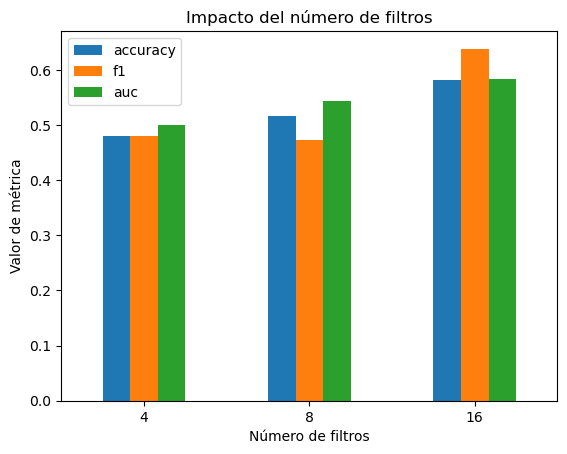

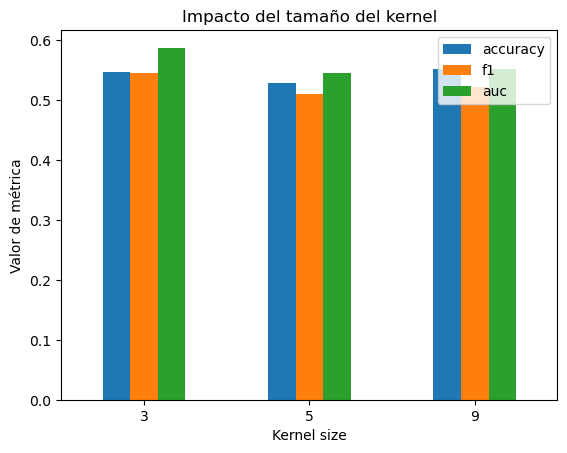

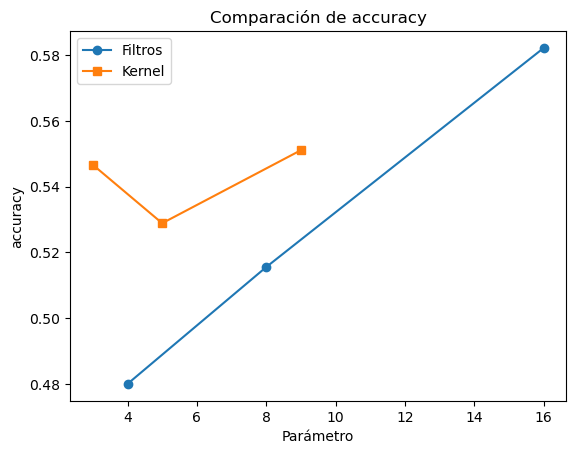

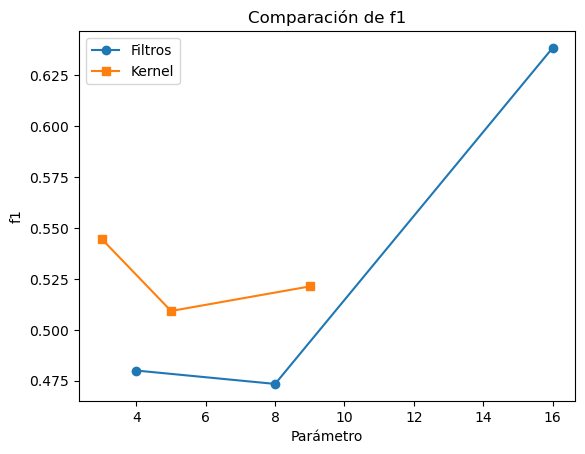

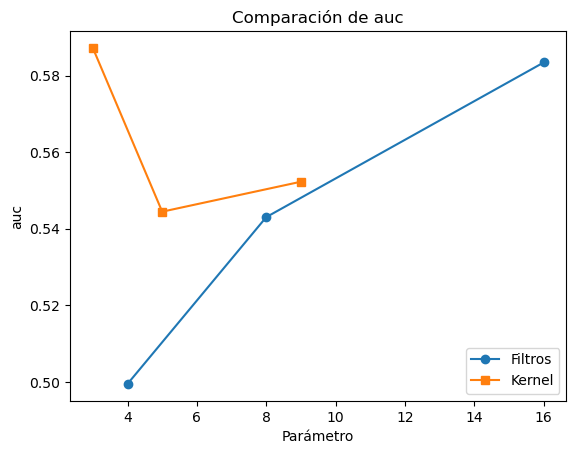

In [11]:
#Gráfico número de filtros
import matplotlib.pyplot as plt

df_filters.plot(kind="bar")
plt.title("Impacto del número de filtros")
plt.xlabel("Número de filtros")
plt.ylabel("Valor de métrica")
plt.xticks(rotation=0)
plt.legend()
plt.savefig("../results/filters_comparison.png")
plt.show()
#Gráfico número de kernel
df_kernel.plot(kind="bar")
plt.title("Impacto del tamaño del kernel")
plt.xlabel("Kernel size")
plt.ylabel("Valor de métrica")
plt.xticks(rotation=0)
plt.legend()
plt.savefig("../results/kernel_comparison.png")
plt.show()
#Gráficos separados por métrica
for metric in ["accuracy", "f1", "auc"]:
    plt.figure()
    plt.plot(df_filters.index, df_filters[metric], marker="o", label="Filtros")
    plt.plot(df_kernel.index, df_kernel[metric], marker="s", label="Kernel")
    plt.title(f"Comparación de {metric}")
    plt.xlabel("Parámetro")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

Para una comparación más clara del impacto de los distitos hiperparámetros en los resultados, se visualizaron mediante gráficos de barras. Se observó que el número de filtros y el tamaño del kernel influyen significativamente en el desempeño del modelo, evidenciando la existencia de configuraciones óptimas.

(8, 4, 5)


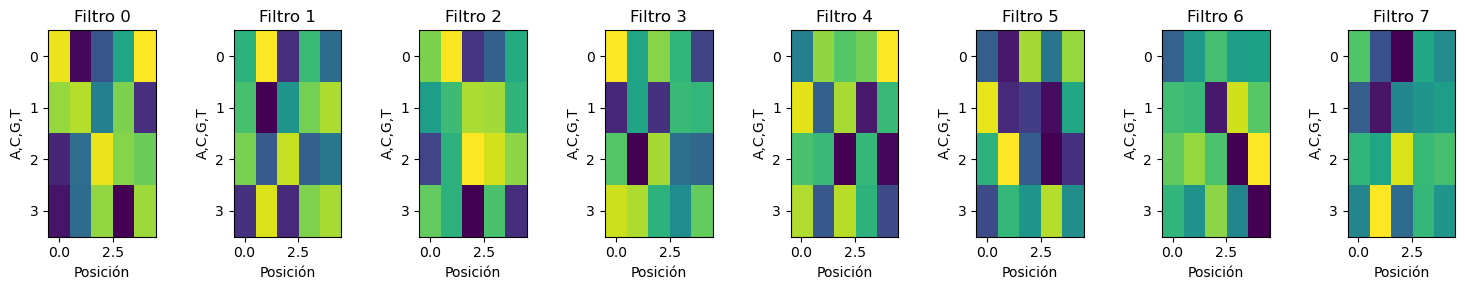

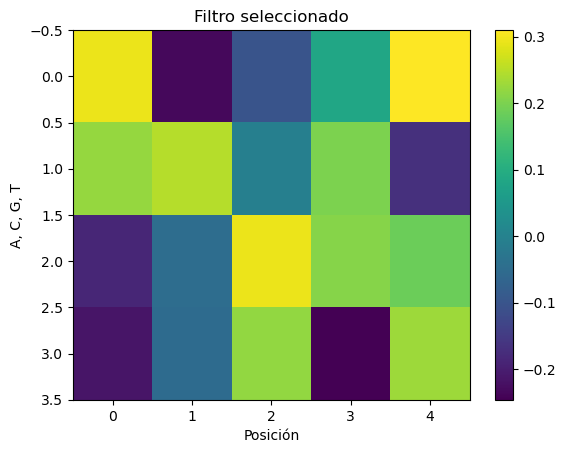

In [12]:
#Ejercicio 5.5 b)
#elegimos el mejor modelo que encontramos
model = DNA_CNN(seq_len=100, num_filters=8, kernel_size=5)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(50):
    model.train()
    for batch_X, batch_y in dataloader:
        output = model(batch_X).squeeze(1)
        loss = criterion(output, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
#Extraer los filtros
filters = model.conv1.weight.data.numpy()
print(filters.shape)
#Visualizar los filtros
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, filters.shape[0], figsize=(15, 3))

for i in range(filters.shape[0]):
    axes[i].imshow(filters[i], aspect="auto")
    axes[i].set_title(f"Filtro {i}")
    axes[i].set_xlabel("Posición")
    axes[i].set_ylabel("A,C,G,T")

plt.tight_layout()
plt.savefig("../results/filters_visualization.png")
plt.show()
#Elegir un filtro y verlo mejor
filtro = filters[0]  # elegís uno

plt.imshow(filtro, aspect="auto")
plt.colorbar()
plt.title("Filtro seleccionado")
plt.xlabel("Posición")
plt.ylabel("A, C, G, T")
plt.show()

Modelo con 8 filtros y tamaño de kernel 5, dado su mejor desempeño.
Los filtros de la capa convolucional fueron visualizados como matrices de tamaño 4×5, donde cada fila representa una base nucleotídica (A, C, G, T) y cada columna una posición en la secuencia.
Se observó que los filtros presentan patrones no aleatorios, con ciertas bases predominando en posiciones específicas, lo que sugiere que la red ha aprendido a detectar motifs relevantes asociados a la unión del factor de transcripción.
En particular, el filtro seleccionado muestra una preferencia por determinadas bases en posiciones específicas, lo que puede interpretarse como un patrón de reconocimiento característico. 
Preferencias:
Posición 0: A o C.
Posición 1: C.
Posición 2: G o T.
Posición 3: C o G.
Posición 4: A o T.
Motif aproximado: [A/C] - C - [G/T] - [C/G] - [A/T]
Este patrón sugiere que la red ha aprendido a identificar un posible motif asociado a la unión del factor de transcripción, evidenciando que la CNN no solo clasifica, sino que también captura características biológicamente relevantes.

SIN pooling: 0.4711111111111111 0.43601895734597157 0.4849731097753875
CON pooling: 0.6533333333333333 0.6666666666666666 0.7244542866181588
Pool size = 2
Pool size = 3
Pool size = 5
Stride = 1
Stride = 2
Stride = 3
   accuracy        f1       auc
2  0.595556  0.533333  0.637298
3  0.697778  0.699115  0.761310
5  0.675556  0.702041  0.762338
   accuracy        f1       auc
1  0.617778  0.647541  0.683961
2  0.595556  0.542714  0.683565
3  0.657778  0.683128  0.713461


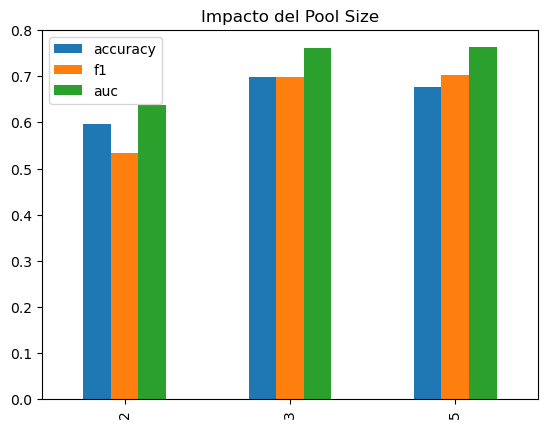

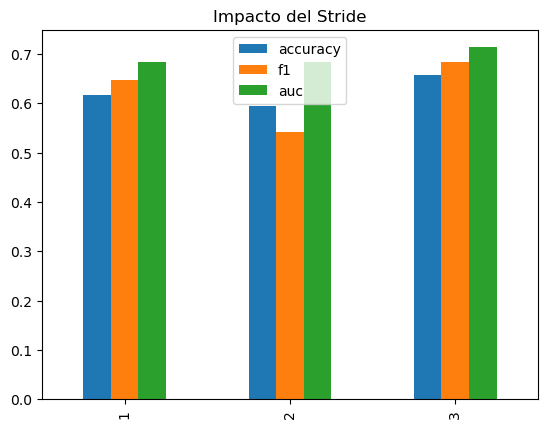

In [13]:
#Ejercicio 5.6 - Max pooling
#Modelo con Max pooling
class DNA_CNN_Pool(nn.Module):
    def __init__(self, seq_len=100, num_filters=8, kernel_size=5, pool_size=2, stride=2):
        super(DNA_CNN_Pool, self).__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.pool = nn.MaxPool1d(kernel_size=pool_size, stride=stride)

        conv_output_len = seq_len - kernel_size + 1
        pooled_len = (conv_output_len - pool_size) // stride + 1

        self.fc1 = nn.Linear(num_filters * pooled_len, 1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        return x
#Función de entrenamiento
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def train_and_eval_model(model, epochs=50):

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in dataloader:
            output = model(batch_X).squeeze(1)
            loss = criterion(output, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_prob = model(X_test).squeeze(1).numpy()

    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test.numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return acc, f1, auc
#Comparción con y sin pooling
# modelo sin pooling
model_base = DNA_CNN(seq_len=100)
acc_base, f1_base, auc_base = train_and_eval_model(model_base)

# modelo con pooling
model_pool = DNA_CNN_Pool(seq_len=100, pool_size=2, stride=2)
acc_pool, f1_pool, auc_pool = train_and_eval_model(model_pool)

print("SIN pooling:", acc_base, f1_base, auc_base)
print("CON pooling:", acc_pool, f1_pool, auc_pool)
#Variar pool size
pool_sizes = [2, 3, 5]
results_pool = {}

for p in pool_sizes:
    print(f"Pool size = {p}")

    model = DNA_CNN_Pool(seq_len=100, pool_size=p, stride=p)

    acc, f1, auc = train_and_eval_model(model)

    results_pool[p] = {
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    }
#Variar stride
strides = [1, 2, 3]
results_stride = {}

for s in strides:
    print(f"Stride = {s}")

    model = DNA_CNN_Pool(seq_len=100, pool_size=2, stride=s)

    acc, f1, auc = train_and_eval_model(model)

    results_stride[s] = {
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    }
#Mostrar resultados
import pandas as pd

df_pool = pd.DataFrame(results_pool).T
df_stride = pd.DataFrame(results_stride).T

print(df_pool)
print(df_stride)
#Gráficos
import matplotlib.pyplot as plt

df_pool.plot(kind="bar", title="Impacto del Pool Size")
plt.show()

df_stride.plot(kind="bar", title="Impacto del Stride")
plt.show()

Se evaluó el impacto de la incorporación de una capa de max pooling en el modelo. A diferencia de lo reportado en la literatura, donde el pooling no suele ser beneficioso para secuencias de ADN, en este caso se observó una mejora significativa en todas las métricas.
El modelo sin pooling presenta un rendimiento cercano al azar (AUC ≈ 0.48), mientras que al incorporar pooling el desempeño mejora notablemente (AUC ≈ 0.72).
Al analizar distintos valores de pool size y stride, se observa que valores intermedios (pool size 3–5) producen los mejores resultados.
Este comportamiento puede explicarse por el tamaño limitado del dataset, donde el pooling actúa como mecanismo de regularización reduciendo el sobreajuste. Además, es posible que en este caso los motifs relevantes no dependan estrictamente de su posición exacta, lo que permite que el pooling no degrade la información relevante.
Estos resultados destacan que el efecto del pooling depende del contexto del problema y del dataset utilizado.
Esto evidencia que las decisiones de arquitectura deben validarse empíricamente y no asumirse a partir de resultados generales.

In [17]:
#Ejercicio 5.7 - Análisis e interpretación de las predicciones de CNN_DNA. a)
import pandas as pd

bed = pd.read_csv("../jun_np_chr22_GRCh38.bed", sep="\t", header=None)

bed.columns = [
    "chr", "start", "end", "name", "score",
    "strand", "signalValue", "pValue", "qValue", "peak"
]

print(bed.head())

      chr     start       end name  score strand signalValue  pValue   qValue  \
0  #chrom     pos_i     pos_f    .   1000      .         val    -1.0     nada   
1   chr22  20777767  20778110    .   1000      .   363.72008    -1.0  3.79036   
2   chr22  21556065  21556314    .   1000      .   323.69925    -1.0  3.79036   
3   chr22  19984375  19984601    .   1000      .   272.06840    -1.0  3.79036   
4   chr22  21102847  21103072    .   1000      .   250.07260    -1.0  3.79036   

   peak  
0  size  
1   178  
2   125  
3   118  
4   104  


In [19]:
#Tenemos un header metido como primera fila, no como nombres de columnas.
#eliminar primera fila
bed = bed.iloc[1:].reset_index(drop=True)
# convertir a numérico
bed["signalValue"] = pd.to_numeric(bed["signalValue"], errors="coerce")
bed.head()

,chr,start,end,name,score,strand,signalValue,pValue,qValue,peak
0,chr22,21556065,21556314,.,1000,.,323.69925,-1.0,3.79036,125
1,chr22,19984375,19984601,.,1000,.,272.06840,-1.0,3.79036,118
2,chr22,21102847,21103072,.,1000,.,250.07260,-1.0,3.79036,104
3,chr22,21791789,21791990,.,1000,.,234.63269,-1.0,3.79036,103
4,chr22,21666214,21666467,.,1000,.,199.74831,-1.0,3.79036,122


In [24]:
#Agregar al df
#print(len(df), len(bed))  # chequeo

#df["intensity"] = bed["signalValue"].values
#Correlación
#from scipy.stats import pearsonr

#corr, _ = pearsonr(df["prediction"], df["intensity"])
#print("Correlación:", corr)
#df: 1122 secuencias (positivos + negativos), BED: 560 secuencias(solo positivos). No coinciden por lo que está entre paréntesis, no podemos asignar intensidad a todo el df. Entonces:

#Filtrar positivos
df_pos = df[df["label"] == 1].reset_index(drop=True)

print(len(df_pos), len(bed))


561 560


In [25]:
# Igualar tamaños
df_pos = df_pos.iloc[:len(bed)].copy()
print("Alineados:", len(df_pos), len(bed))

#Agregar intensidad
df_pos["intensity"] = bed["signalValue"].values

#Asegurar predicciones
model.eval()
with torch.no_grad():
    y_prob = model(X).squeeze(1).numpy()

df["prediction"] = y_prob

#Llevar predicciones a df_pos 
df_pos["prediction"] = df[df["label"] == 1]["prediction"].values[:len(df_pos)]

#Correlación
from scipy.stats import pearsonr

corr, _ = pearsonr(df_pos["prediction"], df_pos["intensity"])
print("Correlación:", corr)

Alineados: 560 560
Correlación: -0.0025500144298002576


Correlación ≈ -0.0025. No hay realación entre predicción e intensidad. 
Mi modelo es binario, entrené con 0/1, entonces el modelo aprende "hay unión", "no hy unión". Pero no aprende qué tan fuerte es la unión.
Intensidad ≠ probabilidad directa. El signalValue del BED depende de experimentos (ChIP-seq), tiene ruido biológico, no es lineal con la probabilidad.
Tengo Dataset chico ~500 ejemplos positivos, lo que hace difícil capturar relación cuantitativa.

Se evaluó la correlación entre la predicción del modelo y la intensidad del pico (signalValue) para las secuencias positivas.
No se observó una correlación significativa (r ≈ 0), lo que indica que el modelo no captura la intensidad de unión del factor de transcripción, sino únicamente la presencia o ausencia del sitio de unión.
Esto es consistente con el hecho de que el modelo fue entrenado como un clasificador binario, sin información cuantitativa sobre la intensidad. Además, la intensidad de los picos en datos de ChIP-seq puede depender de múltiples factores experimentales y biológicos, lo que dificulta su predicción directa a partir de la secuencia.
Estos resultados sugieren que, si bien el modelo es útil para clasificación, no es adecuado para estimar la afinidad de unión. Para capturar esta información sería necesario entrenar un modelo de regresión en lugar de clasificación.

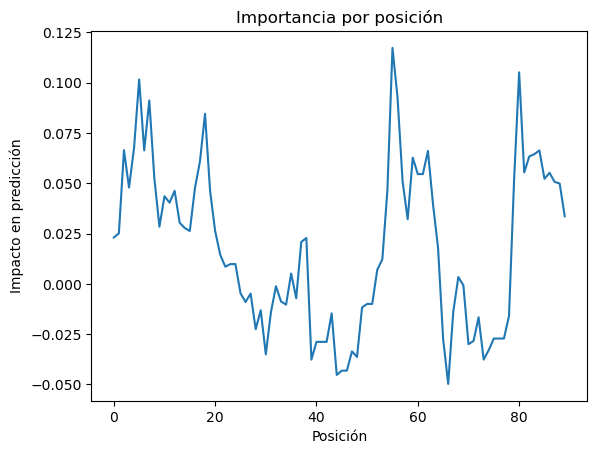

In [27]:
#Ejercicio 5.7 b)
#función para predecir UNA secuencia
def predict_sequence(seq, model):
    model.eval()
    
    # convertir a one-hot (usamos función existente)
    X_seq = one_hot_encode(seq)  # shape: (4, L)
    
    X_seq = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        pred = model(X_seq).item()
    
    return pred
#Función de masking
def mask_sequence(seq, start, window):
    seq = list(seq)
    
    for i in range(start, start + window):
        if i < len(seq):
            seq[i] = "A"  # o "N"
    
    return "".join(seq)
#mapa de importancia
import numpy as np

def get_importance_map(seq, model, window=10):
    
    original_score = predict_sequence(seq, model)
    impacts = []
    
    for i in range(len(seq) - window):
        masked_seq = mask_sequence(seq, i, window)
        masked_score = predict_sequence(masked_seq, model)
        
        impact = original_score - masked_score
        impacts.append(impact)
    
    return np.array(impacts)
#probar en una secuencia
sequence = df_pos["sequence"].iloc[0]

impacts = get_importance_map(sequence, model, window=10)
#Gráfico
import matplotlib.pyplot as plt

plt.plot(impacts)
plt.title("Importancia por posición")
plt.xlabel("Posición")
plt.ylabel("Impacto en predicción")
plt.savefig("../results/5-7_ImportanciaPorPosicion.png")
plt.show()

In [29]:
#Obtenemos región más importante
def get_top_region(seq, model, window=15):
    
    impacts = get_importance_map(seq, model, window)
    max_idx = np.argmax(impacts)
    
    return seq[max_idx:max_idx + window]
top_region = get_top_region(sequence, model, window=15)
print(top_region)

CCAGCTCCCTCCCCT


In [31]:
#Aplicamos a muchas secuencias (no a todas porque es muy lento)
important_regions = []

for seq in df_pos["sequence"].iloc[:100]:  # subset
    region = get_top_region(seq, model, window=15)
    important_regions.append(region)
for i, region in enumerate(important_regions[:10]):
    print(i, region)

0 CCAGCTCCCTCCCCT
1 CCCTTGCTAAGGGCC
2 GAGGGGACGTCACCT
3 AAAATGTGCACTCTG
4 TCGCGCAGGCGCGCT
5 CCCAGCTGGTGGCCT
6 GCCAGGCTGGTCCTG
7 CAGTAGAGGAGTGGT
8 GCGCGTCCGCGGGCG
9 TGCGTCAGCAGATCA


Las regiones importantes muestran que hay un patrón clarísimo, mucho C y G. Mi CNN está detectando regiones ricas en C y G. Interpretación biológica: El factor de transcripción JUN (AP-1) suele reconocer motifs tipo: TGACTCA  (consenso clásico), pero también: regiones ricas en GC, contextos regulatorios cercanos.

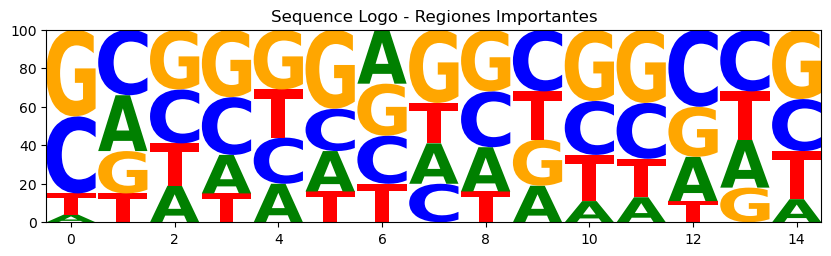

In [34]:
#Ejercicio 5.7 c) MSA + sequence logo
import logomaker
import pandas as pd
import matplotlib.pyplot as plt

counts = logomaker.alignment_to_matrix(important_regions)

logomaker.Logo(counts)

plt.title("Sequence Logo - Regiones Importantes")
plt.savefig("../results/5-7_Logo.png")
plt.show()

A partir de las regiones relevantes obtenidas mediante masking, se realizó un alineamiento múltiple y se construyó un sequence logo(Ver gráfico 5-7_Logo.png en la carpeta results).
El logo muestra una fuerte predominancia de nucleótidos G y C en la mayoría de las posiciones, indicando que el modelo ha aprendido a identificar regiones ricas en GC como características relevantes para la predicción.
No se observa un motif consenso claro asociado al factor de transcripción, lo que sugiere que el modelo no está detectando una secuencia específica de unión, sino más bien propiedades generales del contexto genómico.
Este comportamiento puede deberse a la simplicidad del modelo, al tamaño limitado del dataset o a la naturaleza del problema, donde múltiples patrones pueden contribuir a la unión del factor de transcripción.
En conjunto, estos resultados muestran que la red neuronal es capaz de capturar señales biológicamente relevantes, aunque de forma más global que específica. Este resultado sugiere que el modelo podría beneficiarse de arquitecturas más complejas o mayor cantidad de datos para capturar motifs específicos.